<a href="https://colab.research.google.com/github/BytePhilosopher/Ethiopian-tibeb-with-diffusion-model/blob/main/ethiopian_diffusion.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Diffusion Models on Ethiopian Cultural Patterns
### Tibeb / Meskel-Cross generative modeling — DDPM implementation, mathematical foundations, and a discrete-diffusion bonus on Ge'ez script

**What this notebook contains**
1. History & math: VAE → GAN → Diffusion (short, conceptual, with the key equations)
2. A dataset of Ethiopian *tibeb* (woven border pattern) / Meskel-cross motifs
   - Procedural generator (works offline, guarantees the notebook runs end-to-end)
   - Instructions + a companion script to swap in real scraped images
3. From-scratch DDPM: forward diffusion, U-Net noise predictor, training loop, sampling
4. Bonus: discrete diffusion (D3PM-style, absorbing/mask state) over Ge'ez characters

Run top to bottom on a Colab GPU runtime (Runtime → Change runtime type → GPU).


## 1. From VAEs to GANs to Diffusion

### 1.1 Variational Autoencoders (VAE)

A VAE learns an encoder $q_\phi(z|x)$ and decoder $p_\theta(x|z)$, trained by maximizing the
**evidence lower bound (ELBO)**:

$$
\log p_\theta(x) \ge \mathbb{E}_{q_\phi(z|x)}[\log p_\theta(x|z)] - \mathrm{KL}\big(q_\phi(z|x)\,\|\,p(z)\big)
$$

- First term: reconstruction quality.
- Second term: keeps the latent space close to a prior $p(z) = \mathcal{N}(0, I)$ so we can sample from it.
- **Weakness**: the Gaussian likelihood assumption tends to produce blurry samples, and the KL term
  can be "too strong," collapsing useful information out of $z$ (posterior collapse).

### 1.2 Generative Adversarial Networks (GAN)

A generator $G$ and discriminator $D$ play a minimax game:

$$
\min_G \max_D \; \mathbb{E}_{x\sim p_{data}}[\log D(x)] + \mathbb{E}_{z\sim p(z)}[\log(1 - D(G(z)))]
$$

- No explicit likelihood, no blurry-reconstruction problem — samples can be very sharp.
- **Weakness**: adversarial training is unstable, prone to **mode collapse** (generator finds a few
  outputs that fool $D$ and stops exploring the rest of the data distribution), and there's no
  tractable likelihood to monitor convergence.

### 1.3 Diffusion Models

Diffusion models sidestep both problems: training is a simple, stable regression, and there is no
adversarial game.

**Forward process** — gradually destroy structure by adding Gaussian noise over $T$ steps:

$$
q(x_t \mid x_{t-1}) = \mathcal{N}\big(x_t;\, \sqrt{1-\beta_t}\, x_{t-1},\, \beta_t I\big)
$$

Thanks to the reparameterization trick this has a closed form for *any* $t$ directly from $x_0$
(no need to iterate), with $\alpha_t = 1-\beta_t$ and $\bar\alpha_t = \prod_{s=1}^t \alpha_s$:

$$
q(x_t \mid x_0) = \mathcal{N}\big(x_t;\, \sqrt{\bar\alpha_t}\, x_0,\, (1-\bar\alpha_t) I\big)
\quad\Longrightarrow\quad
x_t = \sqrt{\bar\alpha_t}\, x_0 + \sqrt{1-\bar\alpha_t}\, \epsilon,\quad \epsilon\sim\mathcal{N}(0,I)
$$

**Reverse process** — a neural network learns to undo one noise step at a time:

$$
p_\theta(x_{t-1} \mid x_t) = \mathcal{N}\big(x_{t-1};\, \mu_\theta(x_t, t),\, \Sigma_\theta(x_t,t)\big)
$$

Ho et al. (2020, DDPM) show the variational bound simplifies beautifully if instead of predicting
$\mu_\theta$ directly, the network predicts the **noise** $\epsilon$ that was added:

$$
L_{simple}(\theta) = \mathbb{E}_{x_0,\, t,\, \epsilon}\Big[\, \big\| \epsilon - \epsilon_\theta(x_t, t) \big\|^2 \,\Big]
$$

This is just **regression on noise** — no adversary, no unstable minimax game, and it turns out to
implicitly estimate the score function $\nabla_x \log p_t(x)$ (the score-based-model view of
Song & Ermon), which is why sampling looks like Langevin dynamics: repeatedly step in the
direction of $\epsilon_\theta$ and add a little fresh noise.

**Why diffusion "won"**: stable non-adversarial training + no mode collapse + sharp samples,
at the cost of slow sampling ($T$ sequential network calls) — which later work like DDIM
attacks by skipping steps deterministically.

| | VAE | GAN | Diffusion |
|---|---|---|---|
| Training stability | High | Low | High |
| Sample sharpness | Low (blurry) | High | High |
| Mode coverage | Good | Poor (mode collapse) | Good |
| Sampling speed | Fast (1 pass) | Fast (1 pass) | Slow ($T$ passes) |
| Explicit objective | ELBO (approx. likelihood) | Adversarial (no likelihood) | Simple regression (approx. likelihood) |


## 2. Setup


In [1]:
!pip install -q torch torchvision tqdm

import os, math, random
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


Using device: cuda


## 3. Dataset — Ethiopian tibeb / Meskel-cross patterns

Real scraped datasets of tibeb patterns and Meskel crosses are small (hundreds, not thousands, of
images) and not bundled anywhere as a clean download — so this notebook ships with a **procedural
generator** that draws stylized tibeb border motifs and Meskel-cross-like radial patterns. This
guarantees the notebook trains end-to-end even with zero internet access to image search.

**To use real photos instead** (recommended for your final report): run the companion script
`scrape_tibeb_dataset.py` (provided separately) on a machine with open internet access — it
downloads and center-crops candidate images for search terms like `"tibeb pattern ethiopian
textile"`, `"meskel cross pattern"`, `"habesha kemis border pattern"`. Then set `DATA_DIR` below
to that folder and skip the procedural-generation cell.


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
# --- Option A: point this at a folder of real images (scraped/your own photos) ---
DATA_DIR = "/content/drive/MyDrive/all_images"  # e.g. "/content/tibeb_images" -- set this if you have real images

IMG_SIZE = 32       # keep small for fast Colab training; try 64 if you have time/GPU budget
N_SYNTHETIC = 800    # number of procedurally generated patterns if DATA_DIR is None


Using real images from /content/drive/MyDrive/all_images


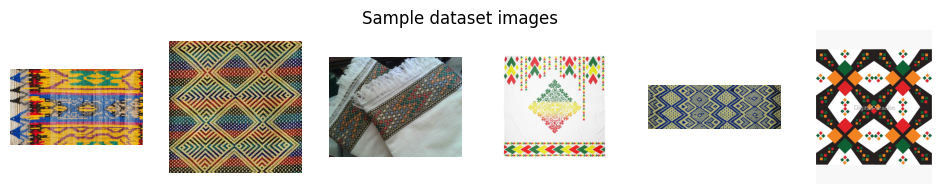

In [4]:
# --- Procedural generator for tibeb-style border patterns & Meskel-cross motifs ---
# This is a stand-in dataset: geometric, repeating, colorful patterns in the same visual
# family as real tibeb weaving and Ethiopian Orthodox cross designs, so the diffusion model
# has real structure (symmetry, repetition, strong color blocks) to learn.

from PIL import Image, ImageDraw

# Colors inspired by the Ethiopian flag + common tibeb palettes
PALETTE = [
    (0, 122, 61),    # green
    (255, 205, 0),   # yellow
    (218, 41, 28),   # red
    (30, 30, 30),    # near-black thread
    (245, 240, 225), # undyed cotton
]

def draw_meskel_cross(draw, cx, cy, size, color, rot=0):
    # Ethiopian (Ge'ez / Meskel) crosses are built from interlocking arms with small
    # trefoil / fan flares at the tips -- approximate with a rotated plus + circles.
    arm = size * 0.42
    thick = size * 0.14
    for angle in (0, 90, 180, 270):
        a = math.radians(angle + rot)
        x2 = cx + arm * math.cos(a)
        y2 = cy + arm * math.sin(a)
        draw.line([(cx, cy), (x2, y2)], fill=color, width=int(thick))
        draw.ellipse([x2 - thick, y2 - thick, x2 + thick, y2 + thick], fill=color)
    draw.ellipse([cx - thick*0.8, cy - thick*0.8, cx + thick*0.8, cy + thick*0.8], fill=color)

def draw_tibeb_border(draw, size, band_colors, n_bands=4):
    # concentric square "woven border" bands, like a tibeb hem pattern
    step = size / (2 * n_bands)
    for i in range(n_bands):
        inset = i * step
        color = band_colors[i % len(band_colors)]
        draw.rectangle([inset, inset, size - inset, size - inset], outline=color,
                        width=max(1, int(step * 0.6)))

def make_synthetic_pattern(size=32, seed=None):
    rng = random.Random(seed)
    img = Image.new("RGB", (size, size), rng.choice(PALETTE))
    draw = ImageDraw.Draw(img)
    style = rng.choice(["cross", "border", "both"])
    band_colors = rng.sample(PALETTE, k=3)
    if style in ("border", "both"):
        draw_tibeb_border(draw, size, band_colors, n_bands=rng.randint(2, 4))
    if style in ("cross", "both"):
        draw_meskel_cross(draw, size/2, size/2, size*0.9, rng.choice(PALETTE),
                           rot=rng.choice([0, 15, 45]))
    return img

if DATA_DIR is None:
    os.makedirs("synthetic_tibeb", exist_ok=True)
    for i in range(N_SYNTHETIC):
        make_synthetic_pattern(IMG_SIZE, seed=i).save(f"synthetic_tibeb/{i:04d}.png")
    DATA_DIR = "synthetic_tibeb"
    print(f"Generated {N_SYNTHETIC} synthetic tibeb/cross patterns in ./{DATA_DIR}")
else:
    print(f"Using real images from {DATA_DIR}")

# preview a few
fig, axes = plt.subplots(1, 6, figsize=(12, 2))
files = sorted(os.listdir(DATA_DIR))[:6]
for ax, f in zip(axes, files):
    ax.imshow(Image.open(os.path.join(DATA_DIR, f)))
    ax.axis("off")
plt.suptitle("Sample dataset images")
plt.show()


In [5]:
# --- Dataset / DataLoader ---
from torchvision import transforms

class PatternDataset(Dataset):
    def __init__(self, folder, img_size):
        self.paths = [os.path.join(folder, f) for f in sorted(os.listdir(folder))
                      if f.lower().endswith((".png", ".jpg", ".jpeg"))]
        self.tf = transforms.Compose([
            transforms.Resize((img_size, img_size)),
            transforms.RandomHorizontalFlip(),
            transforms.RandomRotation(15),
            transforms.ToTensor(),
            transforms.Normalize([0.5]*3, [0.5]*3),  # scale to [-1, 1]
        ])

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        img = Image.open(self.paths[idx]).convert("RGB")
        return self.tf(img)

BATCH_SIZE = 64
dataset = PatternDataset(DATA_DIR, IMG_SIZE)
dataloader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True, drop_last=True, num_workers=2)
print(f"Dataset size: {len(dataset)}  |  batches/epoch: {len(dataloader)}")


Dataset size: 259  |  batches/epoch: 4


## 4. Diffusion schedule

Implements the closed-form forward process $q(x_t|x_0)$ from Section 1. We use $T=300$ steps
with a linear $\beta$ schedule -- fewer than the original DDPM's 1000, to keep Colab training and
sampling fast, at a small cost to sample quality.


In [6]:
T = 300
BETA_START, BETA_END = 1e-4, 0.02

betas = torch.linspace(BETA_START, BETA_END, T)
alphas = 1.0 - betas
alphas_cumprod = torch.cumprod(alphas, dim=0)
alphas_cumprod_prev = F.pad(alphas_cumprod[:-1], (1, 0), value=1.0)

sqrt_alphas_cumprod = torch.sqrt(alphas_cumprod)
sqrt_one_minus_alphas_cumprod = torch.sqrt(1.0 - alphas_cumprod)

# for the reverse process variance (we use the fixed "beta_t" choice, simplest option in the DDPM paper)
posterior_variance = betas * (1.0 - alphas_cumprod_prev) / (1.0 - alphas_cumprod)

def extract(a, t, x_shape):
    # gather per-batch-item schedule values and reshape for broadcasting
    out = a.to(t.device).gather(0, t)
    return out.reshape(t.shape[0], *((1,) * (len(x_shape) - 1)))

def q_sample(x0, t, noise=None):
    '''Forward diffusion: sample x_t directly from x_0 (closed form).'''
    if noise is None:
        noise = torch.randn_like(x0)
    sqrt_ac = extract(sqrt_alphas_cumprod, t, x0.shape)
    sqrt_omac = extract(sqrt_one_minus_alphas_cumprod, t, x0.shape)
    return sqrt_ac * x0 + sqrt_omac * noise


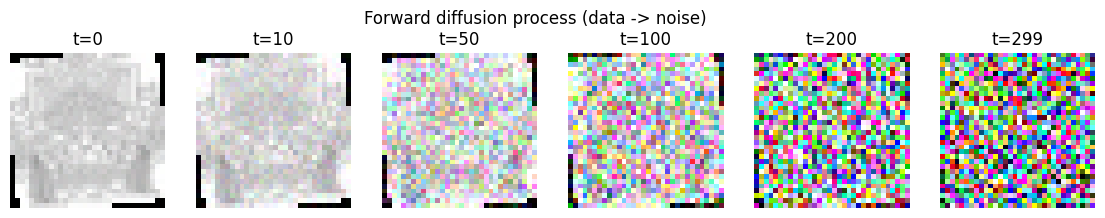

In [7]:
# sanity check: visualize forward diffusion destroying a real pattern
x0 = next(iter(dataloader))[:1].to(betas.device)
steps_to_show = [0, 10, 50, 100, 200, 299]
fig, axes = plt.subplots(1, len(steps_to_show), figsize=(14, 2.5))
for ax, s in zip(axes, steps_to_show):
    t = torch.tensor([s])
    xt = q_sample(x0, t)
    img = (xt[0].clamp(-1, 1) + 1) / 2
    ax.imshow(img.permute(1, 2, 0).numpy())
    ax.set_title(f"t={s}")
    ax.axis("off")
plt.suptitle("Forward diffusion process (data -> noise)")
plt.show()


## 5. Noise-prediction network ($\epsilon_\theta$) -- a small U-Net

Sinusoidal timestep embeddings (as in Transformers) are added into every residual block so the
network knows *how noisy* its input currently is.


In [11]:
class SinusoidalPosEmb(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.dim = dim

    def forward(self, t):
        half = self.dim // 2
        freqs = torch.exp(-math.log(10000) * torch.arange(half, device=t.device) / (half - 1))
        args = t[:, None].float() * freqs[None, :]
        emb = torch.cat([torch.sin(args), torch.cos(args)], dim=-1)
        return emb


class ResBlock(nn.Module):
    def __init__(self, in_ch, out_ch, time_dim):
        super().__init__()
        self.time_mlp = nn.Linear(time_dim, out_ch)
        self.block1 = nn.Sequential(nn.GroupNorm(8, in_ch), nn.SiLU(),
                                     nn.Conv2d(in_ch, out_ch, 3, padding=1))
        self.block2 = nn.Sequential(nn.GroupNorm(8, out_ch), nn.SiLU(),
                                     nn.Conv2d(out_ch, out_ch, 3, padding=1))
        self.res_conv = nn.Conv2d(in_ch, out_ch, 1) if in_ch != out_ch else nn.Identity()

    def forward(self, x, t_emb):
        h = self.block1(x)
        h = h + self.time_mlp(t_emb)[:, :, None, None]
        h = self.block2(h)
        return h + self.res_conv(x)


class SelfAttention(nn.Module):
    def __init__(self, ch):
        super().__init__()
        self.norm = nn.GroupNorm(8, ch)
        self.qkv = nn.Conv2d(ch, ch * 3, 1)
        self.proj = nn.Conv2d(ch, ch, 1)

    def forward(self, x):
        B, C, H, W = x.shape
        h = self.norm(x)
        q, k, v = self.qkv(h).chunk(3, dim=1)
        q = q.reshape(B, C, H * W).permute(0, 2, 1)
        k = k.reshape(B, C, H * W)
        v = v.reshape(B, C, H * W).permute(0, 2, 1)
        attn = torch.softmax(q @ k / math.sqrt(C), dim=-1)
        out = (attn @ v).permute(0, 2, 1).reshape(B, C, H, W)
        return x + self.proj(out)


class UNet(nn.Module):
    def __init__(self, img_ch=3, base_ch=64, time_dim=256):
        super().__init__()
        self.time_mlp = nn.Sequential(
            SinusoidalPosEmb(time_dim),
            nn.Linear(time_dim, time_dim), nn.SiLU(),
            nn.Linear(time_dim, time_dim),
        )

        self.in_conv = nn.Conv2d(img_ch, base_ch, 3, padding=1)

        # down
        self.down1 = ResBlock(base_ch, base_ch, time_dim)
        self.down2 = ResBlock(base_ch, base_ch * 2, time_dim)
        self.pool = nn.AvgPool2d(2)

        # bottleneck
        self.mid1 = ResBlock(base_ch * 2, base_ch * 2, time_dim)
        self.mid_attn = SelfAttention(base_ch * 2)
        self.mid2 = ResBlock(base_ch * 2, base_ch * 2, time_dim)

        # up
        self.up_sample = nn.Upsample(scale_factor=2, mode="nearest")
        self.up1 = ResBlock(base_ch * 2 + base_ch * 2, base_ch, time_dim)
        self.up2 = ResBlock(base_ch + base_ch, base_ch, time_dim)

        self.out_conv = nn.Sequential(
            nn.GroupNorm(8, base_ch), nn.SiLU(),
            nn.Conv2d(base_ch, img_ch, 3, padding=1),
        )

    def forward(self, x, t):
      t_emb = self.time_mlp(t)

      h0 = self.in_conv(x)
      h1 = self.down1(h0, t_emb)

      h1p = self.pool(h1)

      h2 = self.down2(h1p, t_emb)

      h2p = self.pool(h2)

      m = self.mid1(h2p, t_emb)
      m = self.mid_attn(m)
      m = self.mid2(m, t_emb)

      # Decoder
      u1 = self.up_sample(m)

      # Skip connection with h2 (NOT h2p)
      u1 = self.up1(torch.cat([u1, h2], dim=1), t_emb)

      u1 = self.up_sample(u1)

      # Skip connection with h0
      u2 = self.up2(torch.cat([u1, h0], dim=1), t_emb)

      return self.out_conv(u2)


model = UNet(img_ch=3, base_ch=64).to(device)
n_params = sum(p.numel() for p in model.parameters())
print(f"U-Net parameters: {n_params/1e6:.2f}M")


U-Net parameters: 1.57M


## 6. Training ($L_{simple}$)

Each step: sample a random timestep $t$, add the corresponding noise, ask the network to predict
that noise, and do plain MSE regression. No adversary, no KL term to balance -- this is why
diffusion training is comparatively easy to get right.


In [12]:
def train_step(model, x0, betas_len, optimizer):
    b = x0.shape[0]
    t = torch.randint(0, betas_len, (b,), device=x0.device).long()
    noise = torch.randn_like(x0)
    xt = q_sample(x0, t, noise)
    pred_noise = model(xt, t)
    loss = F.mse_loss(pred_noise, noise)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    return loss.item()


epoch   0  loss 0.1307
epoch   5  loss 0.1249
epoch  10  loss 0.1160
epoch  15  loss 0.1118
epoch  20  loss 0.0997
epoch  25  loss 0.1135
epoch  30  loss 0.1098
epoch  35  loss 0.1140
epoch  40  loss 0.1007
epoch  45  loss 0.1261
epoch  50  loss 0.1006
epoch  55  loss 0.0978
epoch  60  loss 0.0901
epoch  65  loss 0.0880
epoch  70  loss 0.0983
epoch  75  loss 0.0973
epoch  80  loss 0.0936
epoch  85  loss 0.0806
epoch  90  loss 0.0972
epoch  95  loss 0.1034
epoch 100  loss 0.0784
epoch 105  loss 0.0905
epoch 110  loss 0.0963
epoch 115  loss 0.0829
epoch 120  loss 0.0769
epoch 125  loss 0.0827
epoch 130  loss 0.0812
epoch 135  loss 0.1027
epoch 140  loss 0.0743
epoch 145  loss 0.0819
epoch 150  loss 0.0935
epoch 155  loss 0.0807
epoch 160  loss 0.0758
epoch 165  loss 0.0713
epoch 170  loss 0.0849
epoch 175  loss 0.0702
epoch 180  loss 0.0664
epoch 185  loss 0.0860
epoch 190  loss 0.0869
epoch 195  loss 0.0686
epoch 199  loss 0.0819


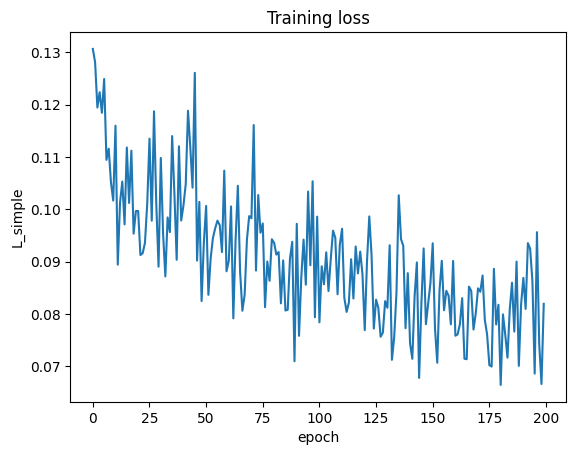

In [15]:
EPOCHS = 200          # bump this up (200-400) if you have GPU time -- patterns need repetition to learn
LR = 2e-4

# move schedule tensors to device once
sqrt_alphas_cumprod = sqrt_alphas_cumprod.to(device)
sqrt_one_minus_alphas_cumprod = sqrt_one_minus_alphas_cumprod.to(device)
betas_d = betas.to(device)
alphas_d = alphas.to(device)
alphas_cumprod_d = alphas_cumprod.to(device)
posterior_variance_d = posterior_variance.to(device)

optimizer = torch.optim.AdamW(model.parameters(), lr=LR)
losses = []

for epoch in range(EPOCHS):
    epoch_losses = []
    for batch in dataloader:
        batch = batch.to(device)
        loss = train_step(model, batch, T, optimizer)
        epoch_losses.append(loss)
    avg = sum(epoch_losses) / len(epoch_losses)
    losses.append(avg)
    if epoch % 5 == 0 or epoch == EPOCHS - 1:
        print(f"epoch {epoch:3d}  loss {avg:.4f}")

plt.plot(losses)
plt.xlabel("epoch"); plt.ylabel("L_simple"); plt.title("Training loss")
plt.show()


## 7. Sampling (reverse process)

Standard DDPM ancestral sampling: start from pure noise $x_T \sim \mathcal{N}(0,I)$ and iteratively
apply the learned reverse step
$x_{t-1} = \frac{1}{\sqrt{\alpha_t}}\Big(x_t - \frac{\beta_t}{\sqrt{1-\bar\alpha_t}}\epsilon_\theta(x_t,t)\Big) + \sigma_t z$.


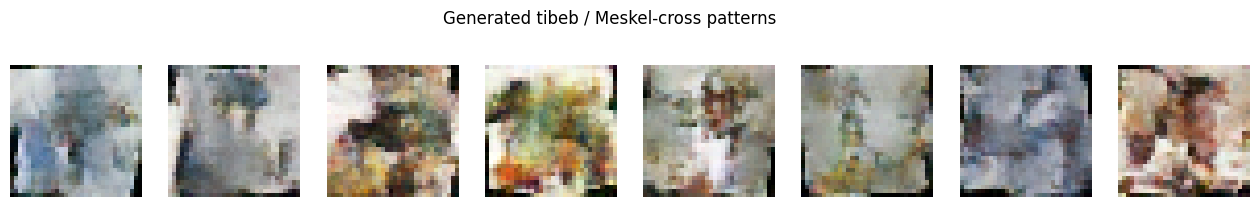

In [16]:
@torch.no_grad()
def sample(model, n_samples, img_size, T):
    model.eval()
    x = torch.randn(n_samples, 3, img_size, img_size, device=device)
    for t_ in reversed(range(T)):
        t = torch.full((n_samples,), t_, device=device, dtype=torch.long)
        pred_noise = model(x, t)

        alpha_t = alphas_d[t_]
        alpha_bar_t = alphas_cumprod_d[t_]
        beta_t = betas_d[t_]

        coef = beta_t / torch.sqrt(1 - alpha_bar_t)
        mean = (1 / torch.sqrt(alpha_t)) * (x - coef * pred_noise)

        if t_ > 0:
            noise = torch.randn_like(x)
            sigma = torch.sqrt(posterior_variance_d[t_])
            x = mean + sigma * noise
        else:
            x = mean
    model.train()
    return x.clamp(-1, 1)

samples = sample(model, n_samples=8, img_size=IMG_SIZE, T=T)
fig, axes = plt.subplots(1, 8, figsize=(16, 2.5))
for ax, img in zip(axes, samples):
    img = (img.cpu() + 1) / 2
    ax.imshow(img.permute(1, 2, 0).numpy())
    ax.axis("off")
plt.suptitle("Generated tibeb / Meskel-cross patterns")
plt.show()


**Tip for your report**: save a grid of samples at multiple training checkpoints (e.g. epoch 10,
30, 60, 100) to visually demonstrate the model learning structure over time -- this is a strong,
easy way to show understanding of the training dynamics, not just a final result.


## 8. Bonus -- Discrete diffusion on Ge'ez / Amharic characters

Gaussian noise doesn't make sense for text: characters are categorical, not points in continuous
space. **D3PM** (Austin et al., 2021, *Structured Denoising Diffusion Models in Discrete
State-Spaces*) generalizes diffusion to discrete data by replacing "add Gaussian noise" with
"apply a stochastic transition matrix" to a categorical distribution over tokens.

### 8.1 The math, briefly

For a token with $K$ possible categories, represent it as a one-hot vector $x_0$. The forward
process is a Markov chain over categorical distributions:

$$
q(x_t \mid x_{t-1}) = \mathrm{Cat}\big(x_t;\, p = x_{t-1} Q_t\big)
$$

where $Q_t$ is a $K\times K$ transition matrix. Two common choices:

- **Uniform**: $Q_t$ mixes every token toward a uniform distribution over the vocabulary.
- **Absorbing** (the one we use below): $Q_t$ moves probability mass toward a special
  `[MASK]` token, i.e. characters randomly get replaced with `[MASK]` as $t$ increases, and by
  $t=T$ everything is `[MASK]`. This is exactly a *diffusion-flavored generalization of BERT's
  masked-language-modeling objective*: instead of masking a fixed 15% once, we mask an
  increasing fraction over $T$ steps and train a model to reconstruct progressively more of the
  sequence.

The reverse model $p_\theta(x_{t-1}\mid x_t)$ is trained to predict the original tokens under
the masked positions -- for the absorbing case, the loss reduces to ordinary cross-entropy at
each masked position, exactly like MLM pretraining.

### 8.2 A small worked demo: character-level absorbing diffusion over Ge'ez script

We train a tiny transformer to reconstruct short Amharic/Ge'ez character sequences from
increasingly masked versions of themselves -- enough to demonstrate the mechanics correctly, not
a state-of-the-art text model.


In [17]:
# --- toy corpus of Ge'ez/Amharic script fragments ---
# (Amharic words/phrases -- feel free to replace with your own corpus, e.g. from your
#  earlier Amharic sentiment-analysis project.)
corpus = [
    "ሰላም ለዓለም",       # "peace to the world"
    "እናመሰግናለን",       # "we thank you"
    "ኢትዮጵያ ቆንጆ ናት",   # "Ethiopia is beautiful"
    "አዲስ አበባ",         # "Addis Ababa"
    "መስቀል በዓል",         # "Meskel holiday"
    "ጥበብ ጨርቅ",          # "tibeb cloth"
    "ቡና ሥነ ሥርዓት",       # "coffee ceremony"
    "ገዳማት እና አብያተ ክርስቲያናት",  # "monasteries and churches"
]

chars = sorted(set("".join(corpus)))
MASK = "[MASK]"
vocab = chars + [MASK]
stoi = {c: i for i, c in enumerate(vocab)}
itos = {i: c for c, i in stoi.items()}
MASK_ID = stoi[MASK]
V = len(vocab)
MAX_LEN = max(len(s) for s in corpus)
print(f"Vocab size: {V}  |  max sequence length: {MAX_LEN}")

def encode(s, pad_to=MAX_LEN):
    ids = [stoi[c] for c in s]
    ids += [MASK_ID] * (pad_to - len(ids))  # pad with MASK id (also acts as padding token here)
    return ids


Vocab size: 40  |  max sequence length: 20


In [18]:
# --- absorbing-state forward process: at diffusion step t, each real token independently
#     becomes [MASK] with probability t/T_text ---
T_TEXT = 20

def forward_mask(ids, t, T):
    ids = ids.clone()
    p_mask = t / T
    mask = torch.rand(ids.shape, device=ids.device) < p_mask
    ids[mask] = MASK_ID
    return ids, mask


In [19]:
# --- tiny transformer to predict original tokens at masked positions ---
class TinyTextDenoiser(nn.Module):
    def __init__(self, vocab_size, seq_len, dim=64, n_layers=2, n_heads=4):
        super().__init__()
        self.tok_emb = nn.Embedding(vocab_size, dim)
        self.pos_emb = nn.Embedding(seq_len, dim)
        self.time_emb = nn.Embedding(T_TEXT + 1, dim)
        layer = nn.TransformerEncoderLayer(d_model=dim, nhead=n_heads,
                                            dim_feedforward=dim * 4, batch_first=True)
        self.encoder = nn.TransformerEncoder(layer, num_layers=n_layers)
        self.out = nn.Linear(dim, vocab_size)

    def forward(self, ids, t):
        B, L = ids.shape
        pos = torch.arange(L, device=ids.device).unsqueeze(0).expand(B, L)
        t_emb = self.time_emb(t).unsqueeze(1).expand(-1, L, -1)
        h = self.tok_emb(ids) + self.pos_emb(pos) + t_emb
        h = self.encoder(h)
        return self.out(h)

text_model = TinyTextDenoiser(V, MAX_LEN).to(device)
text_optimizer = torch.optim.AdamW(text_model.parameters(), lr=3e-4)

data_ids = torch.tensor([encode(s) for s in corpus], device=device)
print("Encoded corpus shape:", data_ids.shape)


Encoded corpus shape: torch.Size([8, 20])


In [20]:
TEXT_EPOCHS = 300
for epoch in range(TEXT_EPOCHS):
    t = torch.randint(1, T_TEXT + 1, (data_ids.shape[0],), device=device)
    xt = torch.stack([forward_mask(data_ids[i], t[i].item(), T_TEXT)[0]
                       for i in range(data_ids.shape[0])])
    logits = text_model(xt, t)
    loss = F.cross_entropy(logits.reshape(-1, V), data_ids.reshape(-1))
    text_optimizer.zero_grad()
    loss.backward()
    text_optimizer.step()
    if epoch % 50 == 0 or epoch == TEXT_EPOCHS - 1:
        print(f"epoch {epoch:3d}  loss {loss.item():.4f}")


epoch   0  loss 3.8482
epoch  50  loss 2.1501
epoch 100  loss 1.6331
epoch 150  loss 1.2321
epoch 200  loss 1.1224
epoch 250  loss 1.0633
epoch 299  loss 1.0649


In [21]:
# --- reverse sampling: start fully masked, iteratively reveal characters ---
@torch.no_grad()
def sample_text(model, seq_len, T):
    ids = torch.full((1, seq_len), MASK_ID, device=device, dtype=torch.long)
    for t_ in reversed(range(1, T + 1)):
        t = torch.full((1,), t_, device=device, dtype=torch.long)
        logits = model(ids, t)
        probs = torch.softmax(logits, dim=-1)
        pred = torch.multinomial(probs.squeeze(0), 1).squeeze(-1)
        # only update positions that are currently masked (absorbing-state reverse step)
        is_masked = ids.squeeze(0) == MASK_ID
        # reveal a fraction of masked positions each step, matching the forward schedule
        reveal_prob = 1.0 / t_
        reveal = is_masked & (torch.rand(seq_len, device=device) < reveal_prob)
        ids[0, reveal] = pred[reveal]
    return "".join(itos[i.item()] for i in ids[0])

model.eval() if False else None  # (no-op, keeps cell self-contained)
for _ in range(5):
    print(sample_text(text_model, MAX_LEN, T_TEXT))


ገስ ሰልእለልዓያ[MASK][MASK]አ[MASK][MASK]ቆ[MASK]አል[MASK]
ጥበስ  አጨ[MASK][MASK][MASK][MASK][MASK][MASK][MASK][MASK][MASK][MASK][MASK]ብ[MASK]
አትምልግዓእስ[MASK][MASK][MASK][MASK] [MASK][MASK]ና[MASK][MASK][MASK][MASK]
መላጆዲ ብንንጆ [MASK][MASK][MASK][MASK][MASK][MASK][MASK][MASK][MASK][MASK]
አላማትሰርለለዓ [MASK][MASK][MASK][MASK][MASK]ጨዓ[MASK]ክ[MASK]


With only 8 training strings this will mostly reproduce/interpolate the toy corpus rather than
generate genuinely novel fluent Amharic -- that's expected and fine for a bonus demo. The point to
make in your report is the **mechanism**: absorbing-state discrete diffusion turns generation into
repeated masked-token prediction, directly generalizing MLM into a full generative model with a
principled forward/reverse noising schedule, mirroring the continuous DDPM derivation in Section 1
but over a categorical state space instead of $\mathbb{R}^n$. For a real project you'd swap this
toy corpus + tiny transformer for a proper Amharic corpus and the full D3PM transition-matrix
formulation (uniform or absorbing $Q_t$, trained on the true variational bound rather than
plain cross-entropy).


## 9. Notes for your writeup

- **Cultural framing**: state upfront that the dataset targets Ethiopian tibeb weaving patterns
  and Meskel/Ge'ez cross motifs, and (if used) the Ge'ez-script discrete diffusion bonus -- this is
  what makes the project distinctive versus a default MNIST/CIFAR diffusion assignment.
- **Be explicit about the synthetic-data caveat** if you don't swap in real scraped images: say
  clearly that the procedural generator is a stand-in with the right *structural* properties
  (repetition, symmetry, strong color blocks) but is not real cultural artwork, and that real
  photos (via the companion scraping script) would be the natural next step.
- **Show the VAE/GAN → diffusion arc** as a short narrative (Section 1 table) rather than
  separate deep dives -- this satisfies the "not too much deep dive, but appreciated" instruction.
- **Quantify something**: even simple metrics (loss curve, or eyeballing sample diversity across
  many samples to argue against mode collapse) make the report feel more rigorous than pictures
  alone.
- **DDIM extension** (optional stretch): if you want to go further, implement deterministic DDIM
  sampling and show that it produces similar samples in far fewer steps (e.g. 50 vs 300) -- a nice,
  short addition that directly demonstrates you understand the sampling-speed tradeoff discussed
  in Section 1.
